In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# abs_phenotypes = True
abs_phenotypes = False
extreme_pheno_dir = 'Bottom'

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",-1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
…,…,…,…,…
"""regulatory""","""fz_blood""","""crimson""","""Flashzoi Blood""",1
"""regulatory""","""abexp_min""","""#80CBC4""","""AbExp min""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1


In [3]:
new_anno_df_path = '/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet'

new_anno_df = (
    pl.read_parquet(new_anno_df_path)
    .with_columns(
        fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
    )
    .with_columns(
        max_fz_blood = pl.col('fz_blood').abs()
    )
    .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
    .lazy()
)

new_anno_df.head().collect()

id,region,fz_blood,max_fz_blood
str,str,f32,f32
"""chr1:3652123:G:A""","""ENSG00000078900""",0.077435,0.077435
"""chr1:3652442:G:T""","""ENSG00000078900""",-0.05002,0.05002
"""chr1:3652966:G:T""","""ENSG00000078900""",0.001191,0.001191
"""chr1:3652415:C:G""","""ENSG00000078900""",0.430102,0.430102
"""chr1:3652543:C:G""","""ENSG00000078900""",0.029333,0.029333


In [4]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205.parquet")
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_df_path is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno_wide = (
    anno
    .with_columns(
        encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
        encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    )
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        (pl.col('encode_all_tf') == True) &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

dist_to_tss,gene_length,abexp_min,id,gpn_star_llr_calibrated_mean,promoterai_abs,cadd_raw,gene_name,esmscoremissense,absplice2_max,region,gpn_score,fz_blood,tss,promoterai,delta_score,loftee_hc,score_pai3d,am_pathogenicity,pangolin_score,strand,absplice_dna_max,abexp_abs_max,max_fz_blood
i64,i64,f32,str,f32,f32,f32,str,f32,f32,str,f32,f32,i64,f32,f32,i8,f32,f32,f32,str,f32,f32,f32
1899,48900,-0.005598,"""chr8:23067132:C:G""",1.001007,0.0,0.158041,"""TNFRSF10B""",0.0,0.000033,"""ENSG00000120889""",0.0,null,23069031,0.0,0.0,0,0.0,0.0,0.0,"""-1""",0.001,0.005598,null
110231,107689,0.002372,"""chr14:31097573:A:C""",-1.465435,0.0,0.247709,"""HECTD1""",0.0,0.0,"""ENSG00000092148""",-3.97,null,31207804,0.0,0.0,0,0.0,0.0,0.0,"""-1""",0.0,0.003333,null
106065,340715,-0.005501,"""chr4:147838127:A:G""",-0.393093,0.0,0.045504,"""ARHGAP10""",0.0,0.000033,"""ENSG00000071205""",-1.43,null,147732062,0.0,0.0,0,0.0,0.0,0.0,"""1""",0.001,0.005501,null
22345,48900,-0.005501,"""chr8:23046686:C:A""",1.97584,0.0,0.226977,"""TNFRSF10B""",0.0,0.000033,"""ENSG00000120889""",0.59,null,23069031,0.0,0.0,0,0.0,0.0,0.0,"""-1""",0.001,0.005501,null
109822,107689,0.002469,"""chr14:31097982:T:G""",0.868484,0.0,-0.180016,"""HECTD1""",0.0,0.0,"""ENSG00000092148""",0.15,null,31207804,0.0,0.0,0,0.0,0.0,0.0,"""-1""",0.0,0.003431,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
791000,1195708,-0.014604,"""chr18:53131196:G:A""",-2.540119,0.0,2.281257,"""DCC""",0.0,0.0,"""ENSG00000187323""",-4.27,null,52340196,0.0,0.0,0,0.0,0.0,0.0,"""1""",0.0,0.014604,null
-4215,134152,0.0,"""chr10:68556121:C:T""",1.002558,0.0,-0.309421,"""TET1""",0.0,0.0,"""ENSG00000138336""",-0.06,null,68560336,0.0,0.0,0,0.0,0.0,0.0,"""1""",0.0,0.0,null
25916,44390,0.002221,"""chr4:44700672:C:A""",1.102638,0.0,0.403116,"""GNPDA2""",0.0,0.000033,"""ENSG00000163281""",-0.13,null,44726588,0.0,0.0,0,0.0,0.0,0.0,"""-1""",0.0,0.003182,null


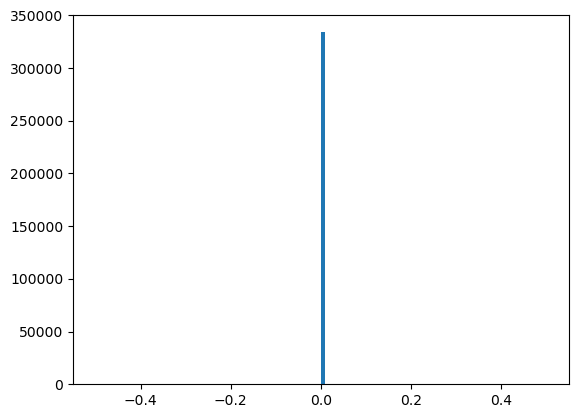

In [5]:
plt.hist(anno_wide['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [6]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'

    (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir', 'regulatory'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="average", descending=True).over(["region", "annotation"]).cast(pl.Float32),
    )

    .drop(['annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr8:23067132:C:G""","""ENSG00000120889""","""cadd_raw""",0.158041,"""genetic_diversity""",-1,265.0
"""chr14:31097573:A:C""","""ENSG00000092148""","""cadd_raw""",0.247709,"""genetic_diversity""",-1,2287.0
"""chr4:147838127:A:G""","""ENSG00000071205""","""cadd_raw""",0.045504,"""genetic_diversity""",-1,254.0
"""chr8:23046686:C:A""","""ENSG00000120889""","""cadd_raw""",0.226977,"""genetic_diversity""",-1,350.0
"""chr14:31097982:T:G""","""ENSG00000092148""","""cadd_raw""",-0.180016,"""genetic_diversity""",-1,460.0
…,…,…,…,…,…,…
"""chr18:53131196:G:A""","""ENSG00000187323""","""abexp_abs_max""",0.014604,"""regulatory_nondir""",-1,2298.0
"""chr10:68556121:C:T""","""ENSG00000138336""","""abexp_abs_max""",0.0,"""regulatory_nondir""",-1,107.0
"""chr4:44700672:C:A""","""ENSG00000163281""","""abexp_abs_max""",0.003182,"""regulatory_nondir""",-1,46.5


## Odds ratio computation

In [7]:
n_steps = 101
min_rank_cutoff = 10
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno_wide.shape[0]])
or_threshold_pheno = 0.9

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
10
11
12
13
15
…
220174
244345
271170


In [8]:
# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        mean_pheno_value_rank=pl.col('mean_pheno_value')
            .rank(method="average")
            .cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile=(
            pl.col('mean_pheno_value_rank') / pl.len()
        ).cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .rename({
        'phenotype': 'olink_prot',
    })
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_corr_df
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "olink_prot", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

/tmp/ipykernel_639211/3879832487.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Executing with odds ratios...


annotation,region,olink_prot,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,i64,u64,u64,u64,u64,f64
"""promoterai""","""ENSG00000125730""","""ENSG00000125730_olink""",333977,42,337,0,0,NaN
"""absplice2_max""","""ENSG00000163162""","""ENSG00000163162_olink""",333977,6,92,0,0,NaN
"""cadd_raw""","""ENSG00000152595""","""ENSG00000152595_olink""",333977,1,24,0,0,NaN
"""cadd_raw""","""ENSG00000134853""","""ENSG00000134853_olink""",333977,2,23,0,0,NaN
"""cadd_raw""","""ENSG00000142798""","""ENSG00000142798_olink""",333977,20,167,0,0,NaN
…,…,…,…,…,…,…,…,…
"""promoterai""","""ENSG00000159640""","""ENSG00000159640_olink""",10,0,0,3,20,NaN
"""absplice_dna_max""","""ENSG00000167601""","""ENSG00000167601_olink""",10,0,0,11,182,NaN
"""delta_score""","""ENSG00000101439""","""ENSG00000101439_olink""",10,0,0,7,62,NaN


## Plotting

In [9]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 10) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""cadd_raw""",1.0,10,-1.0,89,0.0,1.991711,0.568446,3.105865,0.877557,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1.0,10,-1.0,98,0.0,0.898852,0.240937,1.371089,0.426615,"""#942c80""","""GPN-MSA""","""conservation"""
"""gpn_star_llr_calibrated_mean""",1.0,10,-1.0,84,0.0,0.548361,0.231612,1.002322,0.094401,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_abs_max""",1.0,10,-1.0,29,0.0,1.283043,0.594036,2.447353,0.118733,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""abexp_min""",1.0,10,-1.0,37,0.0,1.014894,0.422828,1.843637,0.186151,"""#80CBC4""","""AbExp min""","""regulatory"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""gpn_score""",3.080626,1204,-3.080626,11,0.983796,1.064018,0.152146,1.362225,0.765812,"""#942c80""","""GPN-MSA""","""conservation"""
"""abexp_min""",3.126131,1337,-3.126131,10,0.974675,1.116789,0.130515,1.372599,0.860979,"""#80CBC4""","""AbExp min""","""regulatory"""
"""abexp_abs_max""",3.126131,1337,-3.126131,10,0.959933,1.110465,0.145054,1.39477,0.82616,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


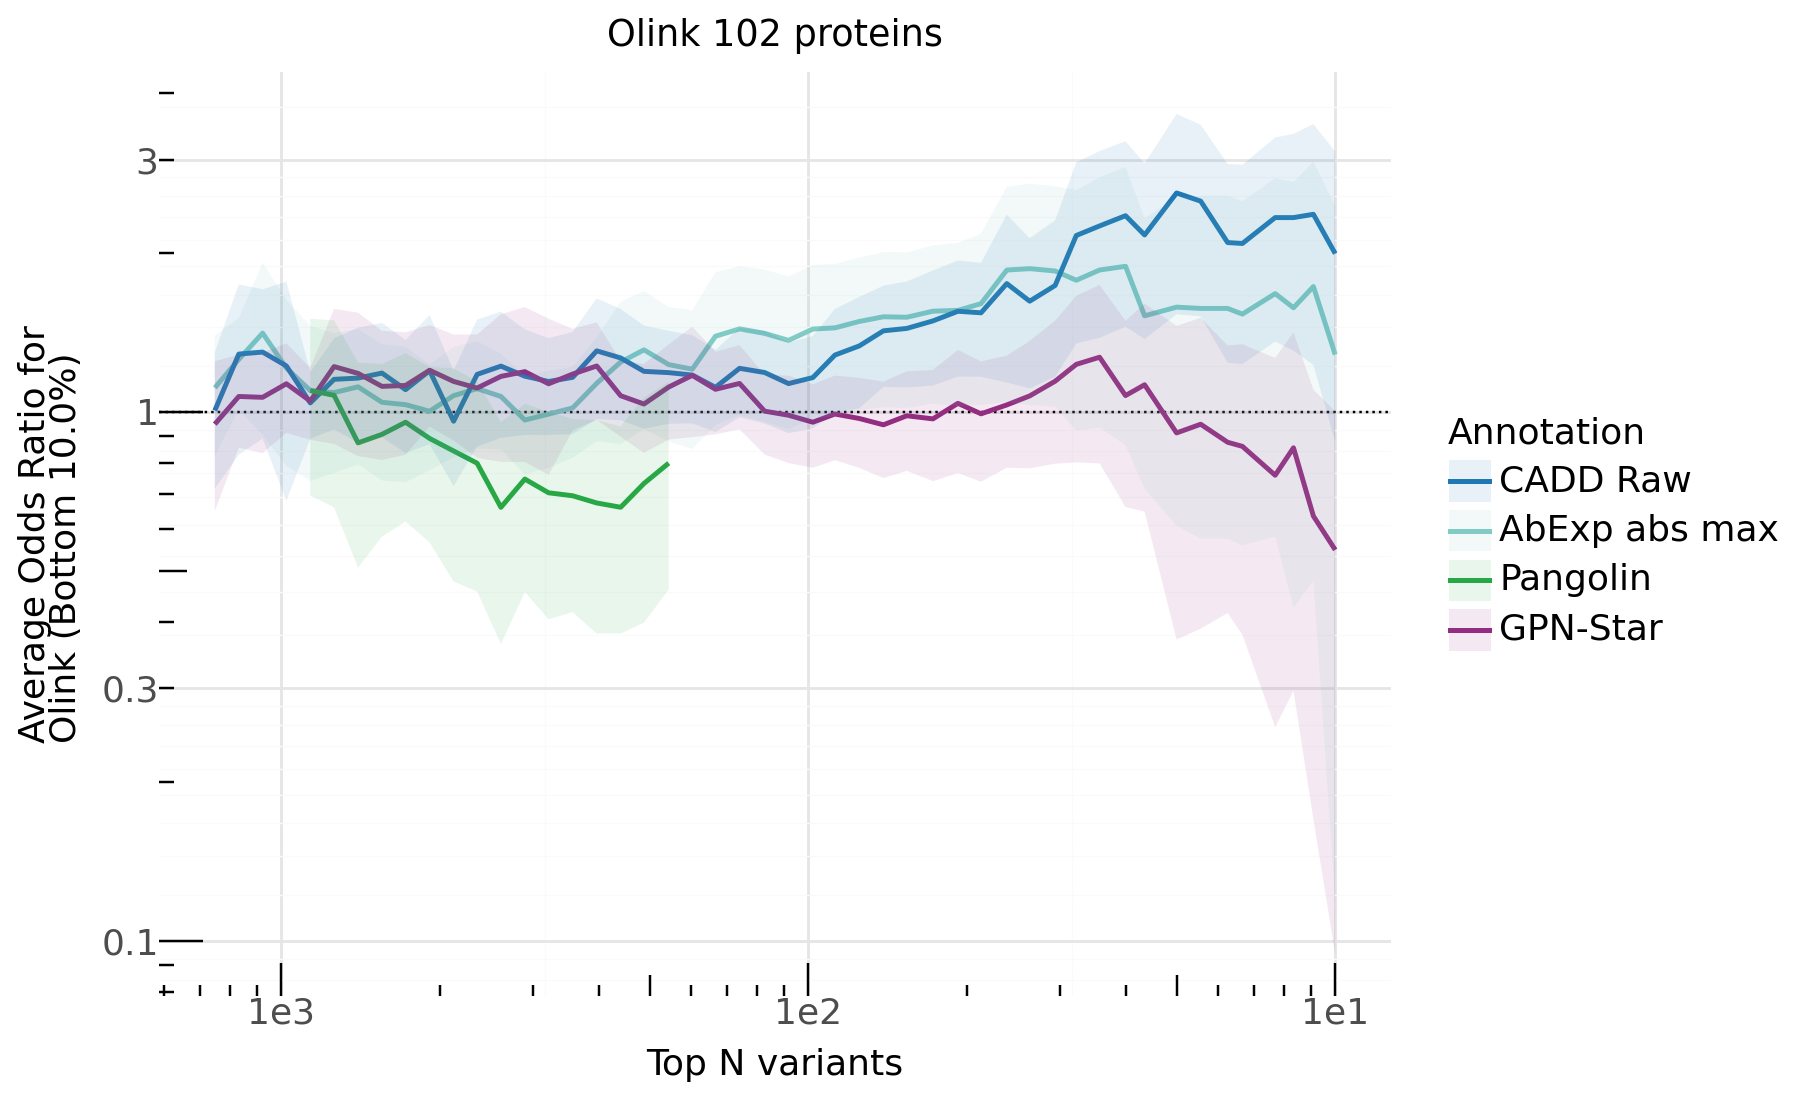

In [10]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -3.5) &
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'delta_score']))
        (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'pangolin_score']))
        # (pl.col('annotation').is_in(['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max', 'promoterai_abs', 'max_fz_blood']))
        # (pl.col('category').is_in(['missense', 'genetic_diversity']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        title=f"Olink {plt_df['n_gene_phenos'].max()} proteins",
        y=f"Average Odds Ratio for\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    # + lims(y=(-0.1, 3.5))
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""cadd_raw""",1.0,10,-1.0,89,0.0,1.991711,0.568446,3.105865,0.877557,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1.0,10,-1.0,98,0.0,0.898852,0.240937,1.371089,0.426615,"""#942c80""","""GPN-MSA""","""conservation"""
"""gpn_star_llr_calibrated_mean""",1.0,10,-1.0,84,0.0,0.548361,0.231612,1.002322,0.094401,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_abs_max""",1.0,10,-1.0,29,0.0,1.283043,0.594036,2.447353,0.118733,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""abexp_min""",1.0,10,-1.0,37,0.0,1.014894,0.422828,1.843637,0.186151,"""#80CBC4""","""AbExp min""","""regulatory"""
